In [1]:
#@title Importing packages
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import functools
import os
from google.colab import drive
from torch.optim import Adam
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
from torchvision.datasets import MNIST
# import tqdm
from tqdm.notebook import tqdm
from torch.utils.data import DataLoader, Subset
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

In [2]:
#@title Defining a time-dependent score-based model (double click to expand or collapse)

class GaussianFourierProjection(nn.Module):
  """Gaussian random features for encoding time steps."""
  def __init__(self, embed_dim, scale=30.):
    super().__init__()
    # Randomly sample weights during initialization. These weights are fixed
    # during optimization and are not trainable.
    self.W = nn.Parameter(torch.randn(embed_dim // 2) * scale, requires_grad=False)
  def forward(self, x):
    x_proj = x[:, None] * self.W[None, :] * 2 * np.pi
    return torch.cat([torch.sin(x_proj), torch.cos(x_proj)], dim=-1)

class Dense(nn.Module):
  """A fully connected layer that reshapes outputs to feature maps."""
  def __init__(self, input_dim, output_dim):
    super().__init__()
    self.dense = nn.Linear(input_dim, output_dim)
  def forward(self, x):
    return self.dense(x)[..., None, None]

class ScoreNet(nn.Module):
  """A time-dependent score-based model built upon U-Net architecture."""

  def __init__(self, marginal_prob_std, channels=[32, 64, 128, 256], embed_dim=256):
    """Initialize a time-dependent score-based network.

    Args:
      marginal_prob_std: A function that takes time t and gives the standard
        deviation of the perturbation kernel p_{0t}(x(t) | x(0)).
      channels: The number of channels for feature maps of each resolution.
      embed_dim: The dimensionality of Gaussian random feature embeddings.
    """
    super().__init__()
    # Gaussian random feature embedding layer for time
    self.embed = nn.Sequential(GaussianFourierProjection(embed_dim=embed_dim),
         nn.Linear(embed_dim, embed_dim))
    # Encoding layers where the resolution decreases
    self.conv1 = nn.Conv2d(1, channels[0], 3, stride=1, bias=False)
    self.dense1 = Dense(embed_dim, channels[0])
    self.gnorm1 = nn.GroupNorm(4, num_channels=channels[0])
    self.conv2 = nn.Conv2d(channels[0], channels[1], 3, stride=2, bias=False)
    self.dense2 = Dense(embed_dim, channels[1])
    self.gnorm2 = nn.GroupNorm(32, num_channels=channels[1])
    self.conv3 = nn.Conv2d(channels[1], channels[2], 3, stride=2, bias=False)
    self.dense3 = Dense(embed_dim, channels[2])
    self.gnorm3 = nn.GroupNorm(32, num_channels=channels[2])
    self.conv4 = nn.Conv2d(channels[2], channels[3], 3, stride=2, bias=False)
    self.dense4 = Dense(embed_dim, channels[3])
    self.gnorm4 = nn.GroupNorm(32, num_channels=channels[3])

    # Decoding layers where the resolution increases
    self.tconv4 = nn.ConvTranspose2d(channels[3], channels[2], 3, stride=2, bias=False)
    self.dense5 = Dense(embed_dim, channels[2])
    self.tgnorm4 = nn.GroupNorm(32, num_channels=channels[2])
    self.tconv3 = nn.ConvTranspose2d(channels[2] + channels[2], channels[1], 3, stride=2, bias=False, output_padding=1)
    self.dense6 = Dense(embed_dim, channels[1])
    self.tgnorm3 = nn.GroupNorm(32, num_channels=channels[1])
    self.tconv2 = nn.ConvTranspose2d(channels[1] + channels[1], channels[0], 3, stride=2, bias=False, output_padding=1)
    self.dense7 = Dense(embed_dim, channels[0])
    self.tgnorm2 = nn.GroupNorm(32, num_channels=channels[0])
    self.tconv1 = nn.ConvTranspose2d(channels[0] + channels[0], 1, 3, stride=1)

    # The swish activation function
    self.act = lambda x: x * torch.sigmoid(x)
    self.marginal_prob_std = marginal_prob_std

  def forward(self, x, t):
    # Obtain the Gaussian random feature embedding for t
    embed = self.act(self.embed(t))
    # Encoding path
    h1 = self.conv1(x)
    ## Incorporate information from t
    h1 += self.dense1(embed)
    ## Group normalization
    h1 = self.gnorm1(h1)
    h1 = self.act(h1)
    h2 = self.conv2(h1)
    h2 += self.dense2(embed)
    h2 = self.gnorm2(h2)
    h2 = self.act(h2)
    h3 = self.conv3(h2)
    h3 += self.dense3(embed)
    h3 = self.gnorm3(h3)
    h3 = self.act(h3)
    h4 = self.conv4(h3)
    h4 += self.dense4(embed)
    h4 = self.gnorm4(h4)
    h4 = self.act(h4)

    # Decoding path
    h = self.tconv4(h4)
    ## Skip connection from the encoding path
    h += self.dense5(embed)
    h = self.tgnorm4(h)
    h = self.act(h)
    h = self.tconv3(torch.cat([h, h3], dim=1))
    h += self.dense6(embed)
    h = self.tgnorm3(h)
    h = self.act(h)
    h = self.tconv2(torch.cat([h, h2], dim=1))
    h += self.dense7(embed)
    h = self.tgnorm2(h)
    h = self.act(h)
    h = self.tconv1(torch.cat([h, h1], dim=1))

    # Normalize output
    h = h / self.marginal_prob_std(t)[:, None, None, None]
    return h

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

Using: cuda


In [4]:
def marginal_prob_std(t, sigma):
  t = torch.tensor(t, device=device)
  return torch.sqrt((sigma**(2 * t) - 1.) / 2. / np.log(sigma))

def diffusion_coeff(t, sigma):
  return torch.tensor(sigma**t, device=device)

In [5]:
sigma =  25
marginal_prob_std_fn = functools.partial(marginal_prob_std, sigma=sigma)
diffusion_coeff_fn = functools.partial(diffusion_coeff, sigma=sigma)

In [6]:
def loss_fn(model, x, marginal_prob_std, eps=1e-5):
  random_t = torch.rand(x.shape[0], device=x.device) * (1. - eps) + eps
  z = torch.randn_like(x)
  std = marginal_prob_std(random_t)
  perturbed_x = x + z * std[:, None, None, None]
  score = model(perturbed_x, random_t)
  loss = torch.mean(torch.sum((score * std[:, None, None, None] + z)**2, dim=(1,2,3)))
  return loss

In [7]:
#@title Training and testing dataset for MNIST

batch_size = 128
train_dataset = MNIST('.', train=True, transform=transforms.ToTensor(), download=True)
test_dataset = MNIST('.', train=False, transform=transforms.ToTensor(), download=True)

print(len(train_dataset))
print(len(test_dataset))

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 489kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.46MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.47MB/s]

60000
10000


In [8]:
even_indices = [i for i, (_, label) in enumerate(train_dataset) if label % 2 == 0]
even_dataset = Subset(train_dataset, even_indices)
data_loader = DataLoader(even_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
images, labels = next(iter(data_loader))

img = images[0]
print("Shape:", img.shape)
print(labels)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Shape: torch.Size([1, 28, 28])
tensor([6, 6, 6, 8, 0, 8, 2, 6, 0, 6, 4, 8, 0, 4, 8, 8, 8, 0, 2, 4, 0, 4, 0, 2,
        8, 2, 2, 4, 4, 4, 2, 0, 2, 4, 2, 2, 0, 2, 2, 0, 2, 4, 8, 8, 2, 0, 2, 6,
        6, 6, 2, 8, 0, 2, 4, 4, 0, 8, 6, 4, 0, 2, 6, 0, 4, 0, 4, 6, 4, 4, 8, 2,
        2, 0, 8, 6, 4, 4, 0, 8, 2, 2, 8, 2, 0, 6, 6, 6, 4, 8, 6, 0, 6, 2, 4, 8,
        0, 4, 8, 4, 2, 8, 6, 0, 2, 6, 0, 8, 2, 6, 4, 6, 6, 0, 2, 4, 4, 0, 0, 4,
        4, 8, 0, 8, 4, 2, 0, 0])


In [12]:
#@title Checking if the drive is mounted or not
if os.path.isdir('/content/drive/MyDrive'):
    print("Drive is mounted")
else:

    print("Drive is not mounted")

Drive is mounted


In [11]:
drive.mount('/content/drive')

Mounted at /content/drive


In [13]:
#@title Score model Eval
score_model = torch.nn.DataParallel(
    ScoreNet(marginal_prob_std=marginal_prob_std_fn)
)

score_model = score_model.to(device)

# Load weights
score_model.load_state_dict(
    torch.load(
        '/content/drive/MyDrive/MTP_Folder/models/mnist_even.pth',
        map_location=device

    )
)

# Evaluation mode
score_model.eval()

DataParallel(
  (module): ScoreNet(
    (embed): Sequential(
      (0): GaussianFourierProjection()
      (1): Linear(in_features=256, out_features=256, bias=True)
    )
    (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (dense1): Dense(
      (dense): Linear(in_features=256, out_features=32, bias=True)
    )
    (gnorm1): GroupNorm(4, 32, eps=1e-05, affine=True)
    (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), bias=False)
    (dense2): Dense(
      (dense): Linear(in_features=256, out_features=64, bias=True)
    )
    (gnorm2): GroupNorm(32, 64, eps=1e-05, affine=True)
    (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), bias=False)
    (dense3): Dense(
      (dense): Linear(in_features=256, out_features=128, bias=True)
    )
    (gnorm3): GroupNorm(32, 128, eps=1e-05, affine=True)
    (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), bias=False)
    (dense4): Dense(
      (dense): Linear(in_features=256, out_features=256,

In [14]:
def median_heuristic(X):
    if X.dim() == 1:
        X = X.reshape(-1, 1)
    dists_sq = torch.cdist(X,X, p=2) ** 2
    H_n = torch.median(dists_sq)
    h = torch.sqrt(H_n / 2.0)
    return h

In [15]:
class PooledKSD:
    def __init__(self, means, sigmas, weights, device, model=None,):
        self.device = device

        self.means = torch.as_tensor(means, dtype=torch.float32, device=device)
        self.sigmas = torch.as_tensor(sigmas, dtype=torch.float32, device=device)
        self.weights = torch.as_tensor(weights, dtype=torch.float32, device=device)

        self.model = model
        self.use_denoiser = model is not None

        # setting denoiser to eval mode
        if self.use_denoiser:
            self.model.eval()

    def score_function(self, x, sigma_noise):
        # estimated score
        if self.use_denoiser:
            original_shape = x.shape
            x_flat = x.reshape(-1, x.shape[-1])
            sigma = torch.full_like(x_flat, sigma_noise)
            with torch.no_grad():
                score = self.model(x_flat, sigma)
            return score.reshape(original_shape)
        else:
            # analytic true score
            x_in = x.clone().detach().requires_grad_(True)
            x_flat = x_in.reshape(-1, x_in.shape[-1])

            means = self.means.view(1, -1)
            sigmas = self.sigmas.view(1, -1)
            weights = self.weights.view(1, -1)
            var = sigmas**2 + sigma_noise**2

            log_components = (torch.log(weights) - 0.5 * torch.log(2 * torch.pi * var) -
                             (x_flat - means)**2 / (2 * var))
            logp = torch.logsumexp(log_components, dim=1)
            score = torch.autograd.grad(logp.sum(), x_in, create_graph=True)[0]
            return score

    def rbf_kernel(self, x1, x2, scale):
        diff = x1 - x2
        return torch.exp(-(diff**2).sum(dim=-1) /(2*scale**2))
    def grad_x1_rbf(self, x1, x2, scale):
        k = self.rbf_kernel(x1, x2, scale)
        return ( -k.unsqueeze(-1)* (x1-x2) / scale**2)
    def grad_x2_rbf(self, x1, x2, scale):
        return -self.grad_x1_rbf( x1, x2, scale)

    def grad_x1_x2_rbf(self, x1, x2, scale):
        diff = x1-x2
        sq = (diff**2).sum(dim=-1)
        k = self.rbf_kernel(x1,x2,scale)
        d = diff.shape[-1]
        return (d/scale**2 -  sq/scale**4)*k

    def u_q(self, x1, x2,scale,sigma_l):
        score1 = self.score_function(x1, sigma_l)
        score2 = self.score_function(x2, sigma_l)
        k = self.rbf_kernel(x1,x2,scale)
        grad1 = self.grad_x1_rbf(x1,x2,scale)
        grad2 = self.grad_x2_rbf( x1,x2,scale)
        grad12 = self.grad_x1_x2_rbf(x1,x2,scale)
        return ((score1*score2).sum(dim=-1)*k + (score1*grad2).sum(dim=-1) + (grad1*score2).sum(dim=-1) + grad12)

    def bootstrap_stat(self, U):
        n = U.shape[0]
        probs = torch.ones(n, device=self.device) / n
        samples = torch.multinomial(probs, num_samples=n, replacement=True)
        w = torch.bincount(samples, minlength=n).float()
        w_centered = (w / n) - (1.0 / n)
        S = w_centered @ U @ w_centered
        diag_correction = torch.sum(w_centered ** 2 * torch.diag(U))
        return S - diag_correction

    def compute_ksd(self, samples, scale):
        samples = samples.to(self.device)
        n = samples.shape[0]
        x_i = samples[:, None, :]
        x_j = samples[None, :, :]
        U = self.u_q(x_i, x_j, scale)
        total = U.sum() - torch.diagonal(U).sum()
        ksd = total / (n * (n - 1))
        return ksd, U

    def pooled_test(self, x_ksd, sigma_list, alpha=0.05, num_boot=300):
        n = x_ksd.shape[0]
        U = torch.zeros((n, n), device=x_ksd.device)
        for sigma_l in sigma_list:
            epsilon = torch.randn_like(x_ksd)
            x_i_tilde = x_ksd + sigma_l * epsilon
            x1 = x_i_tilde[:, None, :]
            x2 = x_i_tilde[None, :, :]
            scale = median_heuristic(x_ksd)
            scale = torch.clamp(scale, min=1e-3)
            U += self.u_q(x1, x2, scale, sigma_l)
        total = U.sum() - torch.diagonal(U).sum()
        ksd = total / (n * (n - 1))
        boot_stats = torch.stack([self.bootstrap_stat(U) for _ in range(num_boot)])
        critical_val = torch.quantile(boot_stats, 1 - alpha)
        reject = (ksd > critical_val).int()
        return reject, ksd, critical_val, boot_stats


In [16]:
class ScoreKSD(PooledKSD):
    def __init__(self, score_model, device, image_shape=None):
        # Dummy GMM parameters – not used because we override score_function
        super().__init__(means=[0.0], sigmas=[1.0], weights=[1.0],
                         device=device, model=None)
        self.score_model = score_model
        self.score_model.eval()
        self.image_shape = image_shape  # e.g., (1, 28, 28) or (3, 32, 32)
        self.current_t = None           # default noise level

    def score_function(self, x, sigma_noise=None):
        if sigma_noise is None:
            if self.current_t is None:
                raise ValueError("sigma_noise must be provided or set current_t")
            sigma_noise = self.current_t

        x = x.to(self.device)
        original_shape = x.shape # (n, 1, d) or (1, n, d)
        # Flatten all but last dimension into batch
        x_flat = x.reshape(-1, x.shape[-1])          # (total_batch, d)
        # Convert to images if needed
        if self.image_shape is not None:
            x_img = x_flat.reshape(-1, *self.image_shape)
        else:
            x_img = x_flat
        t = torch.full((x_flat.shape[0],), sigma_noise,
                       device=self.device, dtype=x.dtype)
        with torch.no_grad():
            score = self.score_model(x_img, t)       # same shape as x_img
        # Flatten score to (total_batch, d)
        score_flat = score.reshape(x_flat.shape[0], -1)
        # Reshape back to the original shape of x
        return score_flat.reshape(original_shape)

    def compute_ksd_with_t(self, samples, t, h=None):
        samples = samples.to(self.device)
        n = samples.shape[0]
        # Flatten if needed
        if samples.dim() > 2:
            samples = samples.reshape(n, -1)
        # Bandwidth
        if h is None:
            h = median_heuristic(samples)
            h = max(h, 1e-3)          # stability
        scale = torch.tensor(h, device=self.device, dtype=samples.dtype)

        # Build U using u_q with sigma_l = t (this will call the neural score because ScoreKSD overrides score_function)
        x1 = samples.unsqueeze(1)      # (n, 1, d)
        x2 = samples.unsqueeze(0)      # (1, n, d)
        U = self.u_q(x1, x2, scale, sigma_l=t)

        U.fill_diagonal_(0)            # KSD uses i ≠ j
        ksd = U.sum() / (n * (n - 1))
        return ksd.item(), U

In [17]:
#@title Langevin MCMC Sampling (fixed time step)

def langevin_refine(score_model, x_init, t, num_steps=100, step_size=1e-3, device=device):
    x = x_init.clone().to(device)
    batch_size = x.shape[0]
    t_batch = torch.ones(batch_size, device=device) * t
    with torch.no_grad():
        for _ in range(num_steps):
            score = score_model(x, t_batch)
            noise = torch.randn_like(x)
            x_mean = x + step_size * score
            x = (x_mean + torch.sqrt(torch.tensor(2 * step_size, device=device)) * noise)

    return x, x_mean


Processing t = 0.25


  0%|          | 0/100 [00:00<?, ?it/s]

/tmp/ipykernel_1913/3978179467.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  t = torch.tensor(t, device=device)
/tmp/ipykernel_1913/98718885.py:45: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  scale = torch.tensor(h, device=self.device, dtype=samples.dtype)



Processing t = 0.27


  0%|          | 0/100 [00:00<?, ?it/s]

...

  0%|          | 0/100 [00:00<?, ?it/s]


Processing t = 0.37


  0%|          | 0/100 [00:00<?, ?it/s]


Processing t = 0.4


  0%|          | 0/100 [00:00<?, ?it/s]

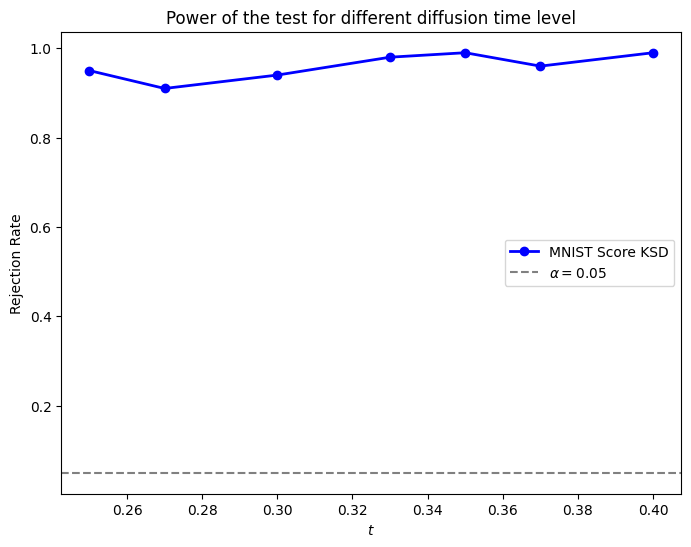

In [20]:
num_trials = 100
n = 128
t_values = [0.25, 0.27, 0.3, 0.33, 0.35, 0.37, 0.4]
num_thresholds = 100
batch_size = 128
num_boot = 200
num_step = 20
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

dataset = MNIST('.', train=False, transform=transforms.ToTensor(), download=True)

even_indices = [i for i, (_, label) in enumerate(dataset) if label % 2 == 0]
even_dataset = Subset(dataset, even_indices)
even_loader = DataLoader(even_dataset, batch_size=batch_size, shuffle=True, num_workers=4)

odd_indices = [i for i, (_, label) in enumerate(dataset) if label % 2 == 1]
odd_dataset = Subset(dataset, odd_indices)
odd_loader = DataLoader(odd_dataset, batch_size=batch_size, shuffle=True, num_workers=4)

def sample_null(n, t):
    data_iter = iter(even_loader)
    x_real, _ = next(data_iter)
    x_real = x_real[:n].to(device)
    t_batch = torch.ones(x_real.shape[0], device=device) * t
    std = marginal_prob_std_fn(t_batch)
    z = torch.randn_like(x_real)
    x_noisy = x_real + z * std[:, None, None, None]
    x_refined, _ = langevin_refine(score_model=score_model,x_init=x_noisy,t=t,num_steps=num_step,step_size=1e-3,device=device)
    return x_refined.view(n, -1) #flatten

def sample_alt(n, t):
    data_iter = iter(odd_loader)
    x_real, _ = next(data_iter)
    x_real = x_real[:n].to(device)
    t_batch = torch.ones(x_real.shape[0], device=device) * t
    std = marginal_prob_std_fn(t_batch)
    z = torch.randn_like(x_real)
    x_noisy = x_real + z * std[:, None, None, None]
    x_refined, _ = langevin_refine(score_model=score_model, x_init=x_noisy, t=t,num_steps=num_step,step_size=1e-3,device=device)
    return x_refined.view(n, -1) #flatten

alpha = 0.05
rejection_rates = []
plt.figure(figsize=(8, 6))
ksd_test = ScoreKSD(score_model=score_model,device=device,image_shape=(1, 28, 28) )

for t in t_values:
    print(f"\nProcessing t = {t}")
    rejections = []
    for rep in tqdm(range(num_trials)):
        X_alt = sample_alt(n, t)
        ksd_alt, U_alt = ksd_test.compute_ksd_with_t(X_alt, t=t)
        boot_stats = torch.stack([ksd_test.bootstrap_stat(U_alt) for _ in range(num_boot)])
        critical_val = torch.quantile(boot_stats, 1 - alpha)
        reject = (ksd_alt > critical_val).int()
        rejections.append(reject.item())
    rejection_rates.append(np.mean(rejections))
plt.plot(t_values, rejection_rates, marker='o', linewidth=2,
         label='MNIST Score KSD', color='blue')
plt.axhline(0.05, color='gray', linestyle='--', label=r'$\alpha=0.05$')
plt.xlabel(r'$t$')
plt.ylabel("Rejection Rate")
plt.title(r"Power of the test for different diffusion time level")
plt.legend()
plt.grid(False)
plt.savefig("vanilla_ksd_score_model_time_step.png", dpi=300, bbox_inches='tight')
plt.show()


Processing t = 0.25


  0%|          | 0/100 [00:00<?, ?it/s]

/tmp/ipykernel_1913/3978179467.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  t = torch.tensor(t, device=device)
/tmp/ipykernel_1913/98718885.py:45: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  scale = torch.tensor(h, device=self.device, dtype=samples.dtype)



Processing t = 0.27


  0%|          | 0/100 [00:00<?, ?it/s]

...

  0%|          | 0/100 [00:00<?, ?it/s]


Processing t = 0.37


  0%|          | 0/100 [00:00<?, ?it/s]


Processing t = 0.4


  0%|          | 0/100 [00:00<?, ?it/s]

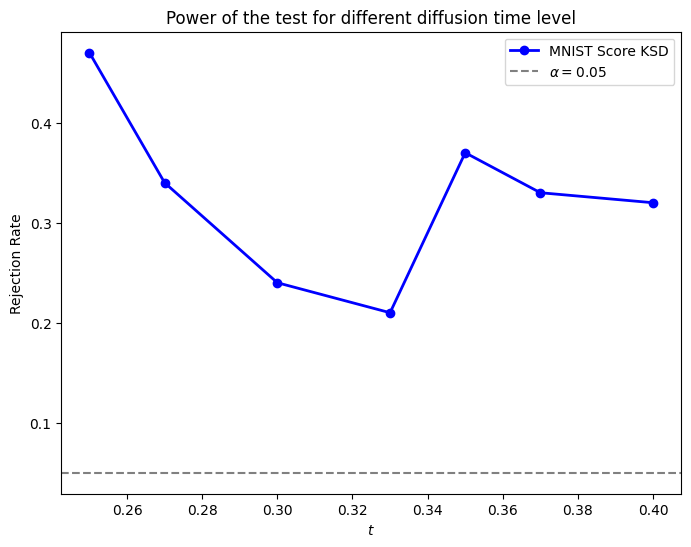

In [22]:
num_trials = 100
n = 128
t_values = [0.25, 0.27, 0.3, 0.33, 0.35, 0.37, 0.4]
num_thresholds = 100
batch_size = 128
num_boot = 200
num_step = 20
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

dataset = MNIST('.', train=False, transform=transforms.ToTensor(), download=True)

even_indices = [i for i, (_, label) in enumerate(dataset) if label % 2 == 0]
even_dataset = Subset(dataset, even_indices)
even_loader = DataLoader(even_dataset, batch_size=batch_size, shuffle=True, num_workers=4)

odd_indices = [i for i, (_, label) in enumerate(dataset) if label % 2 == 1]
odd_dataset = Subset(dataset, odd_indices)
odd_loader = DataLoader(odd_dataset, batch_size=batch_size, shuffle=True, num_workers=4)

alpha = 0.05
rejection_rates_null = []
plt.figure(figsize=(8, 6))
ksd_test = ScoreKSD(score_model=score_model,device=device,image_shape=(1, 28, 28) )

def sample_null(n, t):
    data_iter = iter(even_loader)
    x_real, _ = next(data_iter)
    x_real = x_real[:n].to(device)
    t_batch = torch.ones(x_real.shape[0], device=device) * t
    std = marginal_prob_std_fn(t_batch)
    z = torch.randn_like(x_real)
    x_noisy = x_real + z * std[:, None, None, None]
    return x_noisy.view(n, -1)

for t in t_values:
    print(f"\nProcessing t = {t}")
    rejections = []
    for rep in tqdm(range(num_trials)):
        X_null = sample_null(n, t)
        ksd_null, U_null = ksd_test.compute_ksd_with_t(X_null, t=t)
        boot_stats = torch.stack([ksd_test.bootstrap_stat(U_null) for _ in range(num_boot)])
        critical_val = torch.quantile(boot_stats, 1 - alpha)
        reject = (ksd_null > critical_val).int()
        rejections.append(reject.item())
    rejection_rates_null.append(np.mean(rejections))
plt.plot(t_values, rejection_rates_null, marker='o', linewidth=2,
         label='MNIST Score KSD', color='blue')
plt.axhline(0.05, color='gray', linestyle='--', label=r'$\alpha=0.05$')
plt.xlabel(r'$t$')
plt.ylabel("Rejection Rate")
plt.title(r"Power of the test for different diffusion time level")
plt.legend()
plt.grid(False)
plt.savefig("vanilla_ksd_score_model_time_step_null.png", dpi=300, bbox_inches='tight')
plt.show()


Processing t = 0.25


  0%|          | 0/100 [00:00<?, ?it/s]

/tmp/ipykernel_1913/3978179467.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  t = torch.tensor(t, device=device)
/tmp/ipykernel_1913/98718885.py:45: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  scale = torch.tensor(h, device=self.device, dtype=samples.dtype)



Processing t = 0.27


  0%|          | 0/100 [00:00<?, ?it/s]

...

  0%|          | 0/100 [00:00<?, ?it/s]


Processing t = 0.37


  0%|          | 0/100 [00:00<?, ?it/s]


Processing t = 0.4


  0%|          | 0/100 [00:00<?, ?it/s]

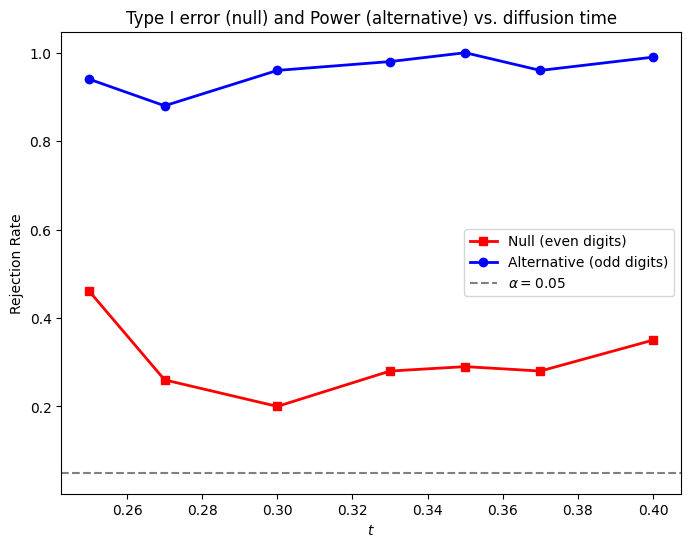

In [24]:
#@title Unified plots
num_trials = 100
n = 128
t_values = [0.25, 0.27, 0.3, 0.33, 0.35, 0.37, 0.4]
num_thresholds = 100
batch_size = 128
num_boot = 200
num_step = 20
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load MNIST test set
dataset = MNIST('.', train=False, transform=transforms.ToTensor(), download=True)

# Even digits (null) and odd digits (alternative)
even_indices = [i for i, (_, label) in enumerate(dataset) if label % 2 == 0]
even_dataset = Subset(dataset, even_indices)
even_loader = DataLoader(even_dataset, batch_size=batch_size, shuffle=True, num_workers=4)

odd_indices = [i for i, (_, label) in enumerate(dataset) if label % 2 == 1]
odd_dataset = Subset(dataset, odd_indices)
odd_loader = DataLoader(odd_dataset, batch_size=batch_size, shuffle=True, num_workers=4)

#sampling functions
def sample_null(n, t):
    #null
    data_iter = iter(even_loader)
    x_real, _ = next(data_iter)
    x_real = x_real[:n].to(device)
    t_batch = torch.ones(x_real.shape[0], device=device) * t
    std = marginal_prob_std_fn(t_batch)
    z = torch.randn_like(x_real)
    x_noisy = x_real + z * std[:, None, None, None]
    return x_noisy.view(n, -1)

def sample_alt(n, t):
    #alternative
    data_iter = iter(odd_loader)
    x_real, _ = next(data_iter)
    x_real = x_real[:n].to(device)
    t_batch = torch.ones(x_real.shape[0], device=device) * t
    std = marginal_prob_std_fn(t_batch)
    z = torch.randn_like(x_real)
    x_noisy = x_real + z * std[:, None, None, None]
    return x_noisy.view(n, -1)

#ksd call
ksd_test = ScoreKSD(score_model=score_model, device=device, image_shape=(1, 28, 28))

#Simulations
alpha = 0.05
rejection_rates_null = []
rejection_rates_alt = []

for t in t_values:
    print(f"\nProcessing t = {t}")
    rejections_null = []
    rejections_alt = []

    for rep in tqdm(range(num_trials)):
        # null
        X_null = sample_null(n, t)
        ksd_null, U_null = ksd_test.compute_ksd_with_t(X_null, t=t)
        boot_stats_null = torch.stack([ksd_test.bootstrap_stat(U_null) for _ in range(num_boot)])
        critical_val_null = torch.quantile(boot_stats_null, 1 - alpha)
        reject_null = (ksd_null > critical_val_null).int()
        rejections_null.append(reject_null.item())

        # alternative
        X_alt = sample_alt(n, t)
        ksd_alt, U_alt = ksd_test.compute_ksd_with_t(X_alt, t=t)
        boot_stats_alt = torch.stack([ksd_test.bootstrap_stat(U_alt) for _ in range(num_boot)])
        critical_val_alt = torch.quantile(boot_stats_alt, 1 - alpha)
        reject_alt = (ksd_alt > critical_val_alt).int()
        rejections_alt.append(reject_alt.item())

    rejection_rates_null.append(np.mean(rejections_null))
    rejection_rates_alt.append(np.mean(rejections_alt))

#plots on the same figure
plt.figure(figsize=(8, 6))
plt.plot(t_values, rejection_rates_null, marker='s', linewidth=2,
         label='Null (even digits)', color='red')
plt.plot(t_values, rejection_rates_alt, marker='o', linewidth=2,
         label='Alternative (odd digits)', color='blue')
plt.axhline(0.05, color='gray', linestyle='--', label=r'$\alpha=0.05$')
plt.xlabel(r'$t$')
plt.ylabel("Rejection Rate")
plt.title("Type I error (null) and Power (alternative) vs. diffusion time")
plt.legend()
plt.grid(False)
plt.savefig("combined_ksd_null_alt.png", dpi=300, bbox_inches='tight')
plt.show()